## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Make charts folder for saved images
import os
os.makedirs('charts', exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load datasets
df = pd.read_csv('Housing.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
# Display first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Shape of the dataset
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 545
Columns: 13


In [4]:
# Target and feature columns
target_col = 'price'
feature_cols = [c for c in df.columns if c != target_col]

print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print(f"Total missing values in dataset: {missing.sum()}")

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values in dataset: 0


## Task 2 — Data Cleaning

In [6]:
# Handle missing values
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for c in numeric_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in categorical_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [7]:
# Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Duplicate rows removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicate rows removed: 0
Rows remaining: 545


In [8]:
# Identify categorical columns for one-hot encoding
binary_cols = [c for c in categorical_cols if set(df[c].unique()) <= {'yes', 'no'}]
multiclass_cols = [c for c in categorical_cols if c not in binary_cols]

print("Binary yes/no columns:", binary_cols)
print("Multi-class categorical columns:", multiclass_cols)

Binary yes/no columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
Multi-class categorical columns: ['furnishingstatus']


In [9]:
# Convert binary yes/no columns to 1/0
for c in binary_cols:
    df[c] = df[c].map({'yes': 1, 'no': 0})

# One-hot encode the remaining multi-class categorical column(s), e.g. furnishingstatus
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [10]:
# All remaining columns are meaningful numeric predictors of price -- no columns dropped,
# since every feature (area, bedrooms, bathrooms, stories, amenities, furnishing) plausibly affects price.
print("Final feature set:")
print([c for c in df.columns if c != 'price'])
print()

print("Final cleaned dataset shape:", df.shape)

Final feature set:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Final cleaned dataset shape: (545, 14)


## Task 3 — Model Building

In [11]:
# Splitting data in training and test sets
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (436, 13)
Test set size: (109, 13)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  R2   : {lr_r2:.4f}")

Linear Regression Performance
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R2   : 0.6529


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Performance")
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  R2   : {rf_r2:.4f}")

Random Forest Regressor Performance
  MAE  : 1,014,947.32
  RMSE : 1,399,769.44
  R2   : 0.6124


In [14]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


## Task 4 — Visualization

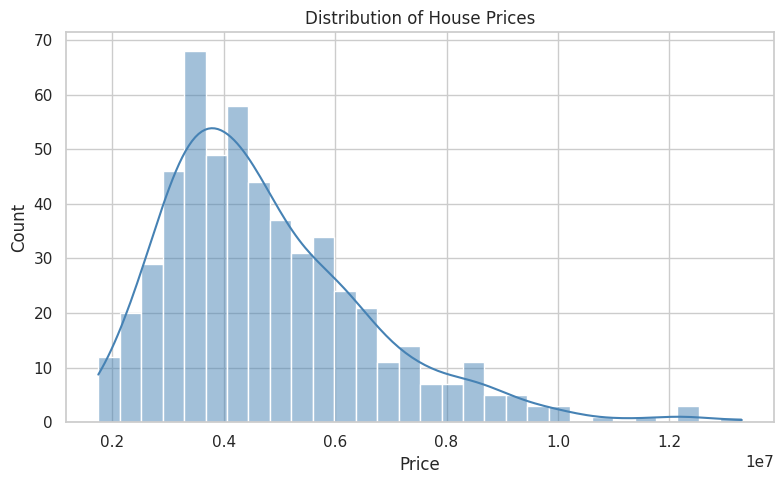

In [15]:
# Chart 1: Distribution of House Prices
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

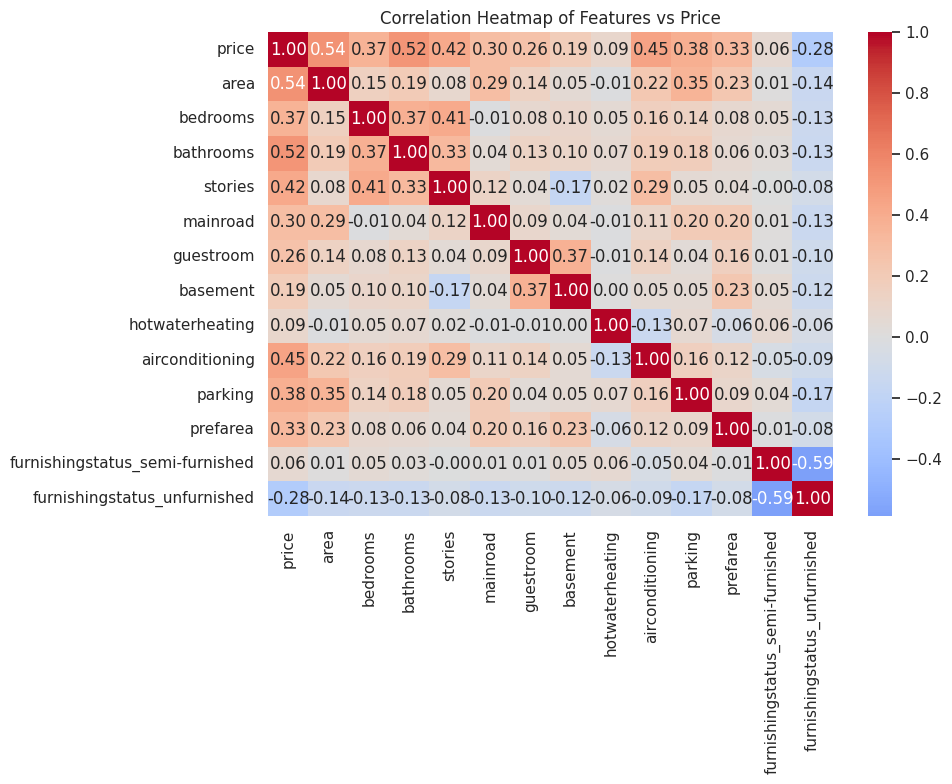

In [16]:
#Chart 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features vs Price')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

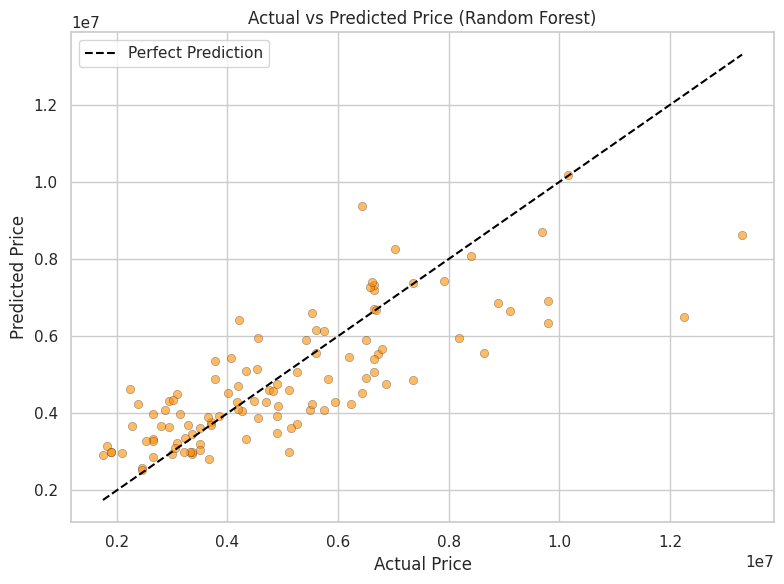

In [17]:
# Chart 3: Actual vs Predicted Price (Random Forest)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkorange', edgecolor='k', linewidth=0.3)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

## Task 5 — Insights & Summary

**Which features influence house price the most?**
According to the Random Forest's feature importances, area is by far the strongest driver of price (close to half of total importance), followed at a distance by the number of bathrooms. Air conditioning, parking, and the number of stories form a second tier of moderately important features, while bedroom count and furnishing status matter comparatively little.

**How accurate was the model (in plain terms)?**
Both models landed in a similar range: Linear Regression scored slightly better (R² ≈ 0.65, MAE ≈ ₹9.7 lakh) than Random Forest (R² ≈ 0.61, MAE ≈ ₹10.1 lakh). In plain terms, the model explains roughly 60–65% of why prices differ from one house to the next, and a typical prediction is off by about ₹9–10 lakh. That's useful for a rough estimate but not precise enough to replace a professional valuation.

**What surprised me in the data?**
Bedroom count turned out to matter far less than expected once area was already in the model — area alone explains most of the price variation, and adding more bedrooms to a similarly-sized house barely moves the price. It was also notable that a simple Linear Regression held its own against Random Forest, suggesting the relationship between area/price is fairly linear for this dataset.

**Recommendation for a real estate business:**
Pricing and marketing should lead with total area and a short list of high-impact amenities (air conditioning, parking, number of stories/bathrooms) rather than bedroom count, since these are what the data shows buyers are actually paying a premium for. A model like this could give agents a quick first-pass price estimate before a full in-person appraisal.
